In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [1]:
import pandas as pd

df = pd.read_excel("/Users/sabina/mosstat_dashboard/data/raw/poverty.xlsx", skiprows=2)
df.head()


,Годы,В процентах от общей численности населения г. Москвы
0,2011,10.0
1,2012,9.4
2,2013,8.7
3,2014,8.8
4,2015,8.9


In [2]:
df = df.rename(columns={df.columns[0]: "year"})
df = df.dropna(subset=["year"])  # удаляем пустые строки


In [3]:
df.columns = ["year", "poverty_percent"]

In [4]:

# 3. Приводим значения к числу
df["poverty_percent"] = pd.to_numeric(df["poverty_percent"], errors="coerce")
df = df.dropna(subset=["poverty_percent"])


In [7]:
# 4. Сохраняем очищенные данные
os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/poverty_cleaned.csv", index=False)
print("CSV сохранён")

CSV сохранён


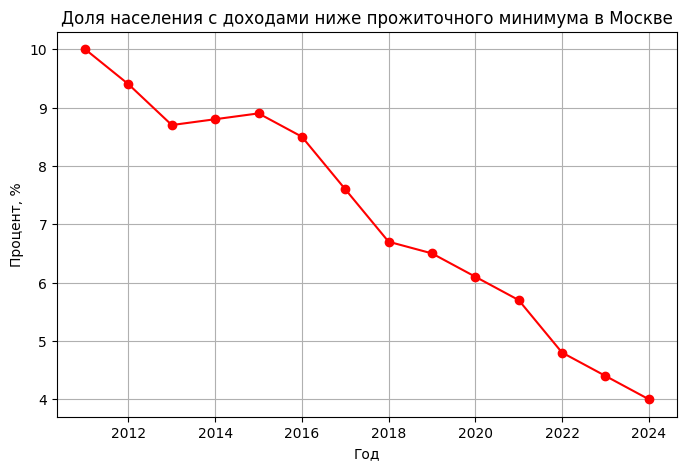

In [8]:
# 5. Строим график динамики бедности
plt.figure(figsize=(8,5))
plt.plot(df["year"], df["poverty_percent"], marker='o', color='red')
plt.title("Доля населения с доходами ниже прожиточного минимума в Москве")
plt.xlabel("Год")
plt.ylabel("Процент, %")
plt.grid(True)
plt.show()


In [9]:
# Если в Excel есть несколько колонок, переведем в длинный формат
if len(df.columns) > 2:
    df_long = df.melt(id_vars=["year"], var_name="indicator", value_name="value")
    df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")
    df_long = df_long.dropna(subset=["value"])
else:
    df_long = df.rename(columns={df.columns[1]: "poverty_percent"})
    df_long["poverty_percent"] = pd.to_numeric(df_long["poverty_percent"], errors="coerce")
    df_long = df_long.dropna(subset=["poverty_percent"])



In [10]:
# Сохраняем обработанный CSV
os.makedirs("data/processed", exist_ok=True)
df_long.to_csv(PROCESSED_PATH, index=False)
print("CSV сохранён")


NameError: name 'PROCESSED_PATH' is not defined

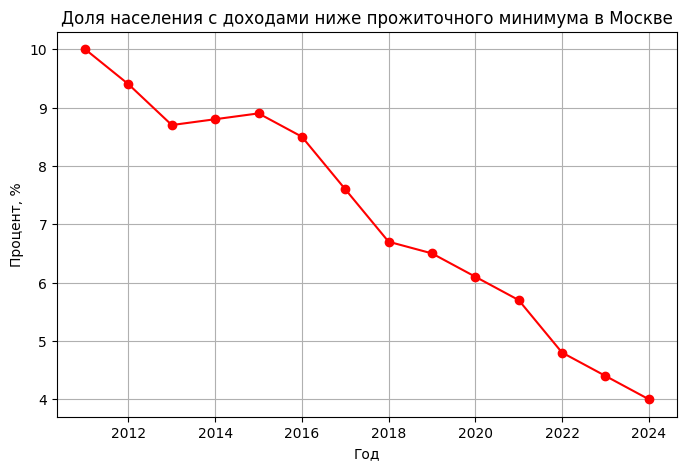

In [11]:
plt.figure(figsize=(8,5))
if "poverty_percent" in df_long.columns:
    plt.plot(df_long["year"], df_long["poverty_percent"], marker='o', color='red')
    plt.ylabel("Процент, %")
else:
    plt.plot(df_long["year"], df_long["value"], marker='o', color='red')
    plt.ylabel("Значение")

plt.title("Доля населения с доходами ниже прожиточного минимума в Москве")
plt.xlabel("Год")
plt.grid(True)
plt.show()


In [12]:
 #Рассчёт годового изменения (прироста)
if "poverty_percent" in df_long.columns:
    df_long["yearly_change"] = df_long["poverty_percent"].diff()
else:
    df_long["yearly_change"] = df_long["value"].diff()

df_long.head(10)

,year,poverty_percent,yearly_change
0,2011,10.0,NaN
1,2012,9.4,-0.6
2,2013,8.7,-0.7
3,2014,8.8,0.1
4,2015,8.9,0.1
5,2016,8.5,-0.4
6,2017,7.6,-0.9
7,2018,6.7,-0.9
8,2019,6.5,-0.2
9,2020,6.1,-0.4


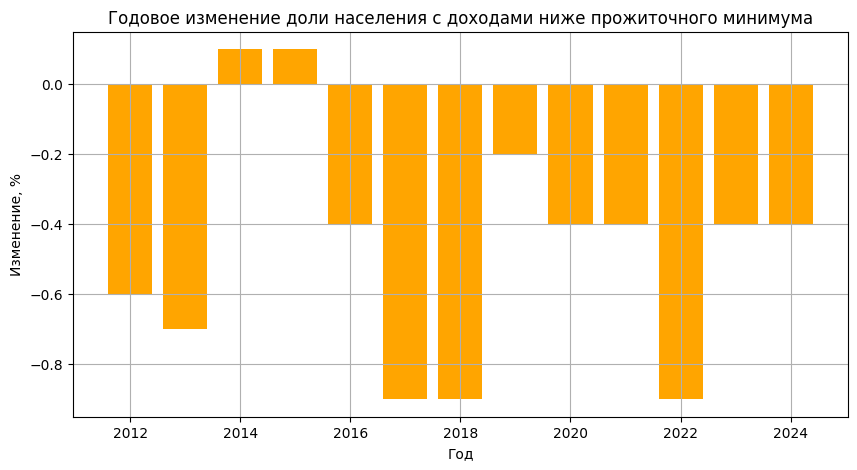

In [13]:
plt.figure(figsize=(10,5))
plt.bar(df_long['year'], df_long['yearly_change'], color='orange')
plt.title("Годовое изменение доли населения с доходами ниже прожиточного минимума")
plt.xlabel("Год")
plt.ylabel("Изменение, %")
plt.grid(True)
plt.show()

In [14]:
max_poverty = df_long['poverty_percent'].max()
min_poverty = df_long['poverty_percent'].min()
year_max = df_long.loc[df_long['poverty_percent'] == max_poverty, 'year'].values[0]
year_min = df_long.loc[df_long['poverty_percent'] == min_poverty, 'year'].values[0]
print(f"Максимальная бедность: {max_poverty}% в {year_max} году")
print(f"Минимальная бедность: {min_poverty}% в {year_min} году")


Максимальная бедность: 10.0% в 2011 году
Минимальная бедность: 4.0% в 2024 году


In [15]:
avg_poverty = df_long['poverty_percent'].mean()
print(f"Средний уровень бедности (2011–2020): {avg_poverty:.2f}%")

Средний уровень бедности (2011–2020): 7.15%


In [16]:
df_long.to_csv("data/processed/poverty_final.csv", index=False)

Доля населения с доходами ниже прожиточного минимума в Москве стабильно снижалась с 10% в 2011 году до 4% в 2024 году.
Средний уровень бедности за период 2011–2020 составил около 7,15%.
Наибольшие снижения наблюдались в 2017–2018 годах, а в 2014–2015 было временное замедление.
Положительная динамика отражает рост доходов населения и эффективность социальных программ.
Временные колебания могут быть связаны с экономическими шоками, девальвацией рубля и инфляцией.
В целом, долгосрочная тенденция указывает на улучшение материального положения москвичей.